# Exploratory Data Analysis
Accidents with personal injury in Germany as recorded by the Unfallatlas, for every year in `fd.DATA_YEARS`. We first check what the data covers and where it is incomplete, then summarise the accidents by **time** (year, hour, day, month), **participant type**, **severity and conditions**, and **geography** (states and the 20 largest cities).

In [1]:
%load_ext autoreload
%autoreload 2
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from urban_mobility import fetch_data as fd
from urban_mobility import plotting as pl
from urban_mobility.utils import cached, load_config, resolve_path
fd.fetch_traffic_data()
cfg = load_config()
YEARS = fd.DATA_YEARS

Already have 2016.csv, skipping...
Already have 2017.csv, skipping...
Already have 2018.csv, skipping...
Already have 2019.csv, skipping...
Already have 2020.csv, skipping...
Already have 2021.csv, skipping...
Already have 2022.csv, skipping...
Already have 2023.csv, skipping...
Already have 2024.csv, skipping...
Already have 2025.csv, skipping...


## The Data
One row per accident. The columns we use:
- **Location:** `ULAND` (state), `UREGBEZ`, `UKREIS`, `UGEMEINDE` and the district (Kreis) key `District_key`; coordinates in metres (`LINREFX`, `LINREFY`, EPSG:25832) and degrees (`XGCSWGS84`, `YGCSWGS84`).
- **Time:** `UJAHR`, `UMONAT`, `USTUNDE`, `UWOCHENTAG` (1 = Sunday).
- **Severity:** `UKATEGORIE` (1 = fatal, 2 = serious, 3 = light injury).
- **Accident:** `UART` (kind of collision) and `UTYP1` (accident type, see `fd.UTYP1_LABELS`).
- **Conditions:** `ULICHTVERH` (0 = daylight, 1 = twilight, 2 = darkness), `USTRZUSTAND` (0 = dry, 1 = wet, 2 = icy).
- **Participants:** `IstRad`, `IstPKW`, `IstFuss`, `IstKrad`, `IstGkfz`, `IstSonstige` (1 if a bicycle, car, pedestrian, motorcycle, goods vehicle or other participant was involved; one accident can have several).

In [2]:
df = pd.concat(fd.get_dfs(YEARS).values(), ignore_index=True)
print(f"{len(df):,} accidents, {df.shape[1]} columns, {YEARS[0]}-{YEARS[-1]}")
df.head()

2,371,026 accidents, 24 columns, 2016-2025


,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,UART,...,IstPKW,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,District_key
0,01,0,53,120,2016,1,9,5,2,8,...,1,0,0,0.0,0,606982.3940,5.954660e+06,10.621659,53.729615,01053
1,01,0,57,010,2016,1,17,3,3,1,...,1,0,0,0.0,0,574882.5330,6.011441e+06,10.149176,54.245453,01057
2,01,0,62,008,2016,1,0,5,3,9,...,1,0,0,0.0,0,599934.6875,5.964609e+06,10.518094,53.820403,01062
3,01,0,03,000,2016,1,15,5,3,5,...,0,0,0,0.0,1,610709.3487,5.968284e+06,10.683021,53.851243,01003
4,01,0,55,028,2016,1,14,1,3,8,...,1,0,0,0.0,0,605690.7904,6.009152e+06,10.620986,54.219459,01055


In [3]:
# Missing values per column
df.isna().sum()[lambda s: s > 0]

IstGkfz    195229
dtype: int64

Only `IstGkfz` has missing values: the 2017 file has no goods-vehicle column. Sums treat these as 0, so goods-vehicle counts for 2017 are too low.

### Coverage
Not every state reports accidents from 2016. The table counts accidents per state and year; a 0 means the state is missing.

In [4]:
df_States = fd.get_state_population()  # population per state and year (Destatis)
state_names = df_States.drop_duplicates("ULAND").set_index("ULAND")["state"]
pd.crosstab(df["ULAND"].map(state_names), df["UJAHR"])

UJAHR,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ULAND,,,,,,,,,,
Baden-Württemberg,33931,33553,34028,32964,28450,28133,30494,31502,31405,32042
Bayern,50121,49108,49760,47461,41424,42244,44680,46247,46446,46938
Berlin,0,0,13652,13390,11810,11309,12348,12329,12428,13280
Brandenburg,0,8407,8637,8691,7679,7646,7942,8216,8365,8459
Bremen,2932,3000,3107,2940,2419,2337,2497,2703,2609,2575
Hamburg,7215,7079,7176,6827,6096,6397,7174,7332,7031,7057
Hessen,19678,19494,19811,18951,15873,15867,17463,18255,17947,18578
Mecklenburg-Vorpommern,0,0,0,0,4427,4334,4508,4601,4639,4867
Niedersachsen,0,27014,27320,26908,23622,24604,26523,26605,26451,24556


All 16 states report only from 2020. Totals over all states therefore compare different sets of states across years, so the yearly trend below uses only the states that report in every year, and the per-capita rates further down use only the years a state or district has data, each with that year's population.

## Accident Trends Over Time
### Yearly Trend

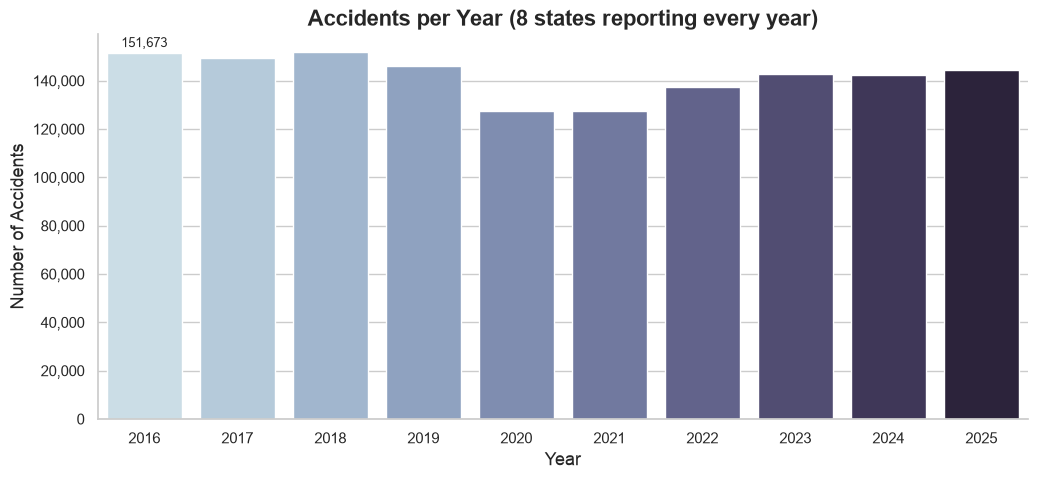

In [5]:
every_year = df.groupby("ULAND")["UJAHR"].nunique().eq(len(YEARS))
counts = df[df["ULAND"].map(every_year)]["UJAHR"].value_counts()
ax = pl.bar_counts(
    counts,
    f"Accidents per Year ({every_year.sum()} states reporting every year)",
    "Year",
    "Number of Accidents",
    gradient=True,
)
ax.figure.set_size_inches(12, 5)
plt.show()

In the 8 states that report every year, accidents dropped from about 150,000 a year in 2016-2018 to about 127,000 in 2020 and 2021 (COVID-19 lockdowns), then recovered to about 144,000 in 2025, still below the pre-pandemic level.

## Accident Trends Over Time

Analyzing the time dimension for accident occurrence reveals several clear patterns.

### Hourly Trends: Rush Hour Spikes

Accidents spike during typical rush hours, correlating with peak traffic volume.

- **Morning Peak:** A sharp increase is visible around 7:00 AM.
- **Afternoon Peak:** A second, larger peak occurs around 4:00 PM (16:00).
- **Overnight Low:** Conversely, accident occurrences are lowest in the early morning (1:00 AM - 5:00 AM), almost certainly due the lower traffic volume.

---

### Weekly Trends: Workdays vs. Weekends

Accident volume is highest during workdays (Monday-Friday), peaking on Friday. There is a noticeable drop on weekends (Saturday and Sunday), which likely correlates with lower commuter traffic volumes on those days.

---

### Monthly Trends: Summer Increases

The summer months see a higher number of accidents. This might seem counter-intuitive, as one might expect hazardous winter weather to cause more incidents. However, this trend could be explained by:

- Increased overall traffic (e.g., holiday and leisure travel).
- A higher number of vulnerable road users, such as cyclists (`IstRad`) and motorcyclists (`IstKrad`), being on the road.


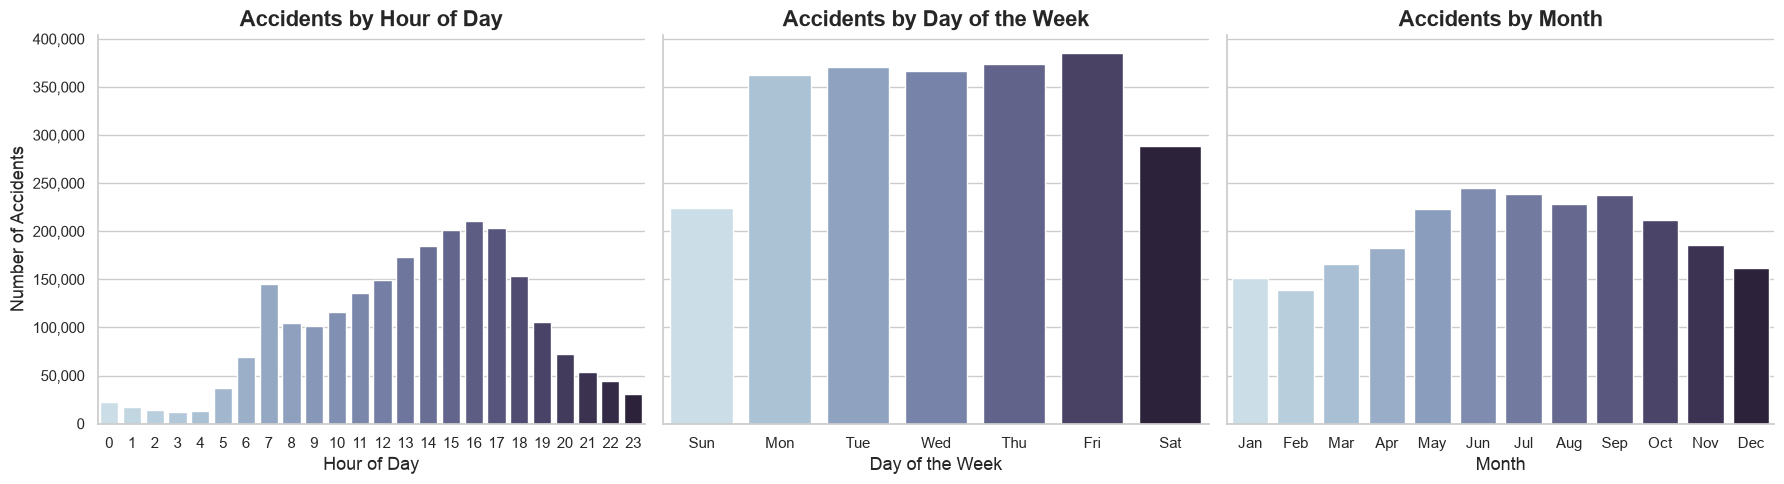

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True)
for ax, (col, title, labels) in zip(
    axes,
    [
        ("USTUNDE", "Hour of Day", None),
        ("UWOCHENTAG", "Day of the Week", dict(zip(range(1, 8), pl.WEEKDAYS))),
        ("UMONAT", "Month", dict(zip(range(1, 13), pl.MONTHS))),
    ],
):
    pl.bar_counts(
        df[col].value_counts(), f"Accidents by {title}", title, "Number of Accidents",
        labels=labels, gradient=True, annotate=False, ax=ax,
    )
fig.tight_layout()
plt.show()

## Accident Participant Trends

Taking a closer look at _who_ is involved in the accidents reveals strong seasonal patterns, especially for vulnerable road users.

### Seasonal Spike: Bicycles and Motorbikes

- **Summer Increase:** Both the total count and the relative share of bicycles (`IstRad`) and motorbikes (`IstKrad`) involved in accidents increase significantly during the summer months.
- **Reason:** This is expected, as the number of bicycle and motorbike riders is certainly higher in warmer weather. This group can be identified as the main driver for the increased _overall_ accident frequency seen in the summer.

---

### Inverse Trend: Pedestrians

- **Winter Increase:** A noteworthy observation is that pedestrians (`IstFuss`) show the opposite relationship. The share and absolute number of pedestrian-involved accidents are higher in the winter months.
- **Reason:** This is likely due to pedestrians being less visible during the darker winter days, while the total number of pedestrians on the road is likely similar to the summer months.


In [7]:
# Participant counts per month (Jan..Dec), shared by the two charts below
accident_types = ["IstRad", "IstPKW", "IstFuss", "IstKrad", "IstGkfz", "IstSonstige"]
monthly_accident_counts = (
    df.groupby("UMONAT")[accident_types].sum().rename(index=dict(zip(range(1, 13), pl.MONTHS)))
)

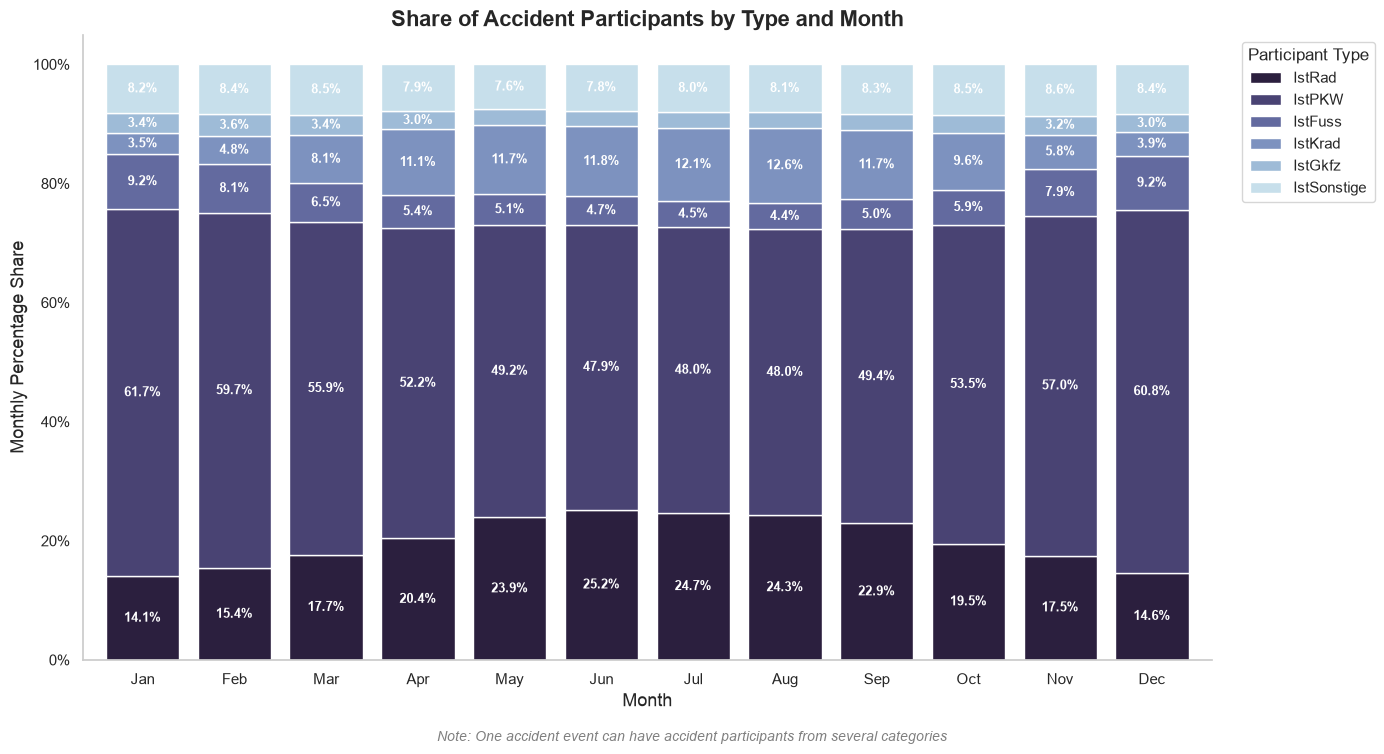

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
pl.stacked_bar(
    monthly_accident_counts,
    "Share of Accident Participants by Type and Month",
    "Month",
    "Monthly Percentage Share",
    pct=True,
    label_fn=lambda v: f"{v:.1f}%" if v > 3 else "",
    ax=ax,
)
ax.legend(title="Participant Type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.text(
    0.5,
    0.01,
    "Note: One accident event can have accident participants from several categories",
    ha="center",
    va="bottom",
    fontsize=10,
    fontstyle="italic",
    color="grey",
)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

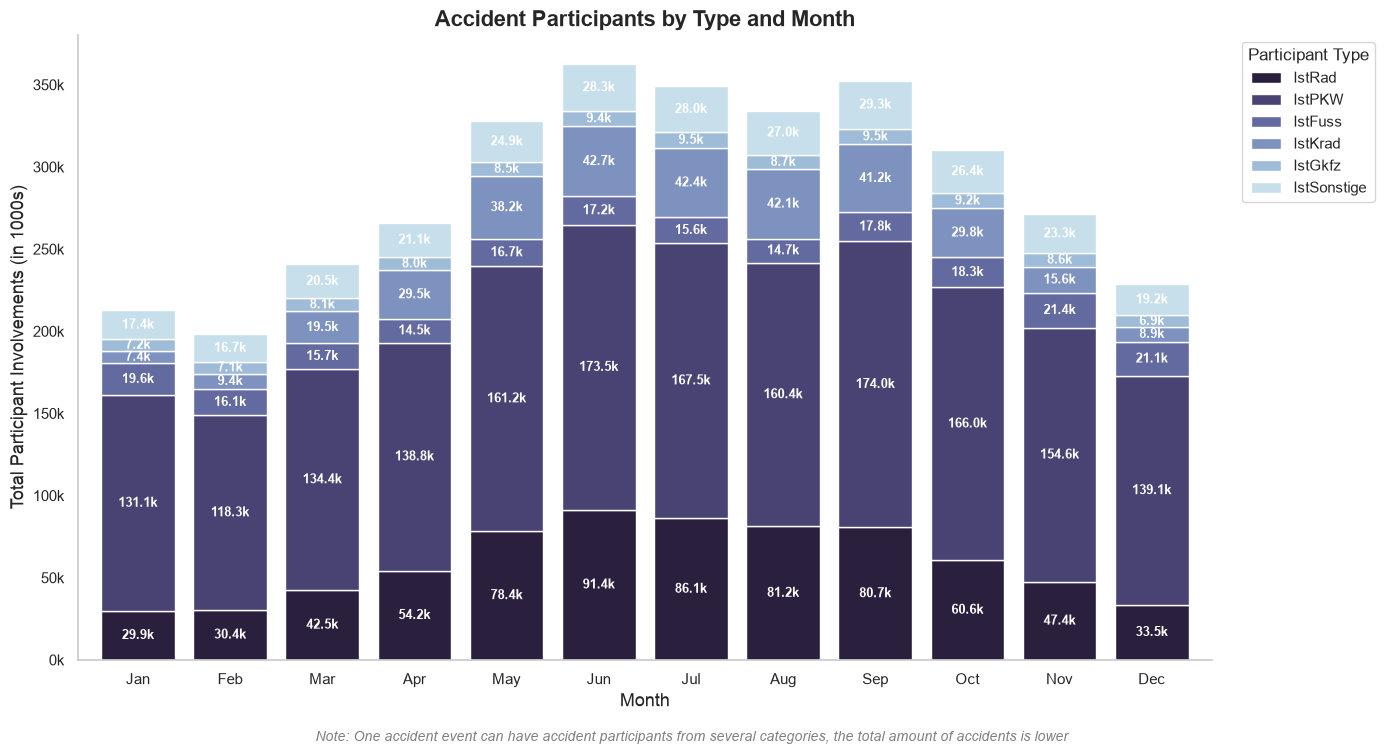

In [9]:
fig, ax = plt.subplots(figsize=(14, 8))
pl.stacked_bar(
    monthly_accident_counts,
    "Accident Participants by Type and Month",
    "Month",
    "Total Participant Involvements (in 1000s)",
    label_fn=lambda v: f"{v / 1000:.1f}k" if v >= 1000 else "",
    ax=ax,
)
ax.yaxis.set_major_formatter(lambda x, _: f"{x / 1000:,.0f}k")
ax.legend(title="Participant Type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.text(
    0.5,
    0.01,
    "Note: One accident event can have accident participants from several categories, the total amount of accidents is lower",
    ha="center",
    va="bottom",
    fontsize=10,
    fontstyle="italic",
    color="grey",
)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Severity and Conditions

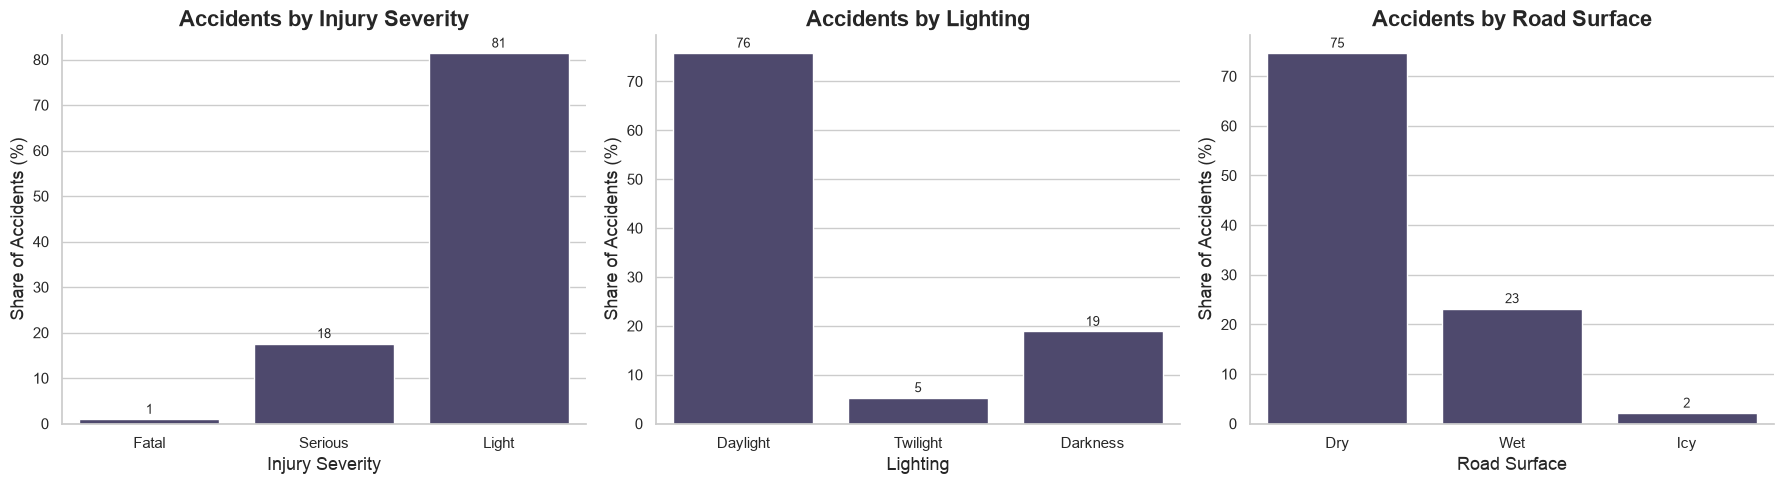

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
for ax, (col, title, labels) in zip(
    axes,
    [
        ("UKATEGORIE", "Injury Severity", {1: "Fatal", 2: "Serious", 3: "Light"}),
        ("ULICHTVERH", "Lighting", {0: "Daylight", 1: "Twilight", 2: "Darkness"}),
        ("USTRZUSTAND", "Road Surface", {0: "Dry", 1: "Wet", 2: "Icy"}),
    ],
):
    counts = df[col].value_counts()
    pl.bar_counts(counts / counts.sum() * 100, f"Accidents by {title}", title, "Share of Accidents (%)", labels=labels, ax=ax)
fig.tight_layout()
plt.show()

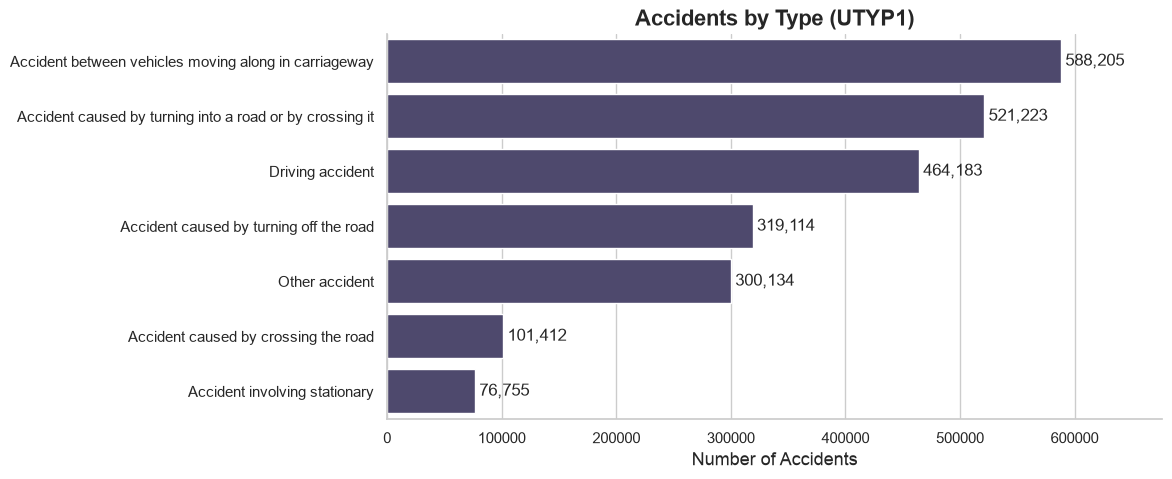

In [11]:
counts = df["UTYP1"].map(fd.UTYP1_LABELS).value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
pl.hbar(counts.index, counts.values, "Accidents by Type (UTYP1)", "Number of Accidents", "", ax=ax)
ax.set_xlim(0, counts.max() * 1.15)
plt.show()

Most accidents (81%) involve only light injuries; 18% involve a serious and 1% a fatal injury. About three quarters happen in daylight and on a dry road. Collisions between vehicles moving along the carriageway (25%) and accidents when turning into or crossing a road (22%) are the most common types.

## Geography
### States

In [12]:
# Accidents per 1000 inhabitants and year, over the years each state has data: each
# year's accidents count against that year's population
state_years = (
    df.groupby(["ULAND", "UJAHR"]).size().rename("AccidentCount").reset_index()
    .merge(df_States, on=["ULAND", "UJAHR"])
)
df_accident_per_population = state_years.groupby(["ULAND", "state"], as_index=False).agg(
    AccidentCount=("AccidentCount", "sum"),
    Years=("UJAHR", "nunique"),
    PersonYears=("population", "sum"),
)
df_accident_per_population["AccidentsPer1000"] = (
    df_accident_per_population["AccidentCount"] / df_accident_per_population["PersonYears"] * 1000
)
# Load the geospatial data for German states
geodata_url = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/2_hoch.geo.json"
gdf_germany = cached(
    f"{cfg.output.artifacts}/summary/germany_states.parquet",
    lambda: gpd.read_file(geodata_url),
    gpd.read_parquet,
    lambda gdf, path: gdf.to_parquet(path),
    force=cfg.run.force_recompute,
)
# Merge data with the geospatial data using state names
# (the 'name' column of the map data matches the 'state' column of our data)
merged_gdf = gdf_germany.merge(
    df_accident_per_population, left_on="name", right_on="state", how="left"
)
df_accident_per_population.sort_values("AccidentsPer1000", ascending=False)

,ULAND,state,AccidentCount,Years,PersonYears,AccidentsPer1000
3,04,Bremen,27119,10,6890775,3.935552
0,01,Schleswig-Holstein,111839,10,29215633,3.828053
1,02,Hamburg,69384,10,18452176,3.760207
8,09,Bayern,464429,10,131222663,3.539244
10,11,Berlin,100546,8,29336953,3.427282
2,03,Niedersachsen,233603,9,71965680,3.246033
11,12,Brandenburg,74042,9,22815048,3.245314
14,15,Sachsen-Anhalt,61829,9,19526779,3.166370
4,05,Nordrhein-Westfalen,390092,7,125799990,3.100891
9,10,Saarland,27603,9,8983343,3.072687


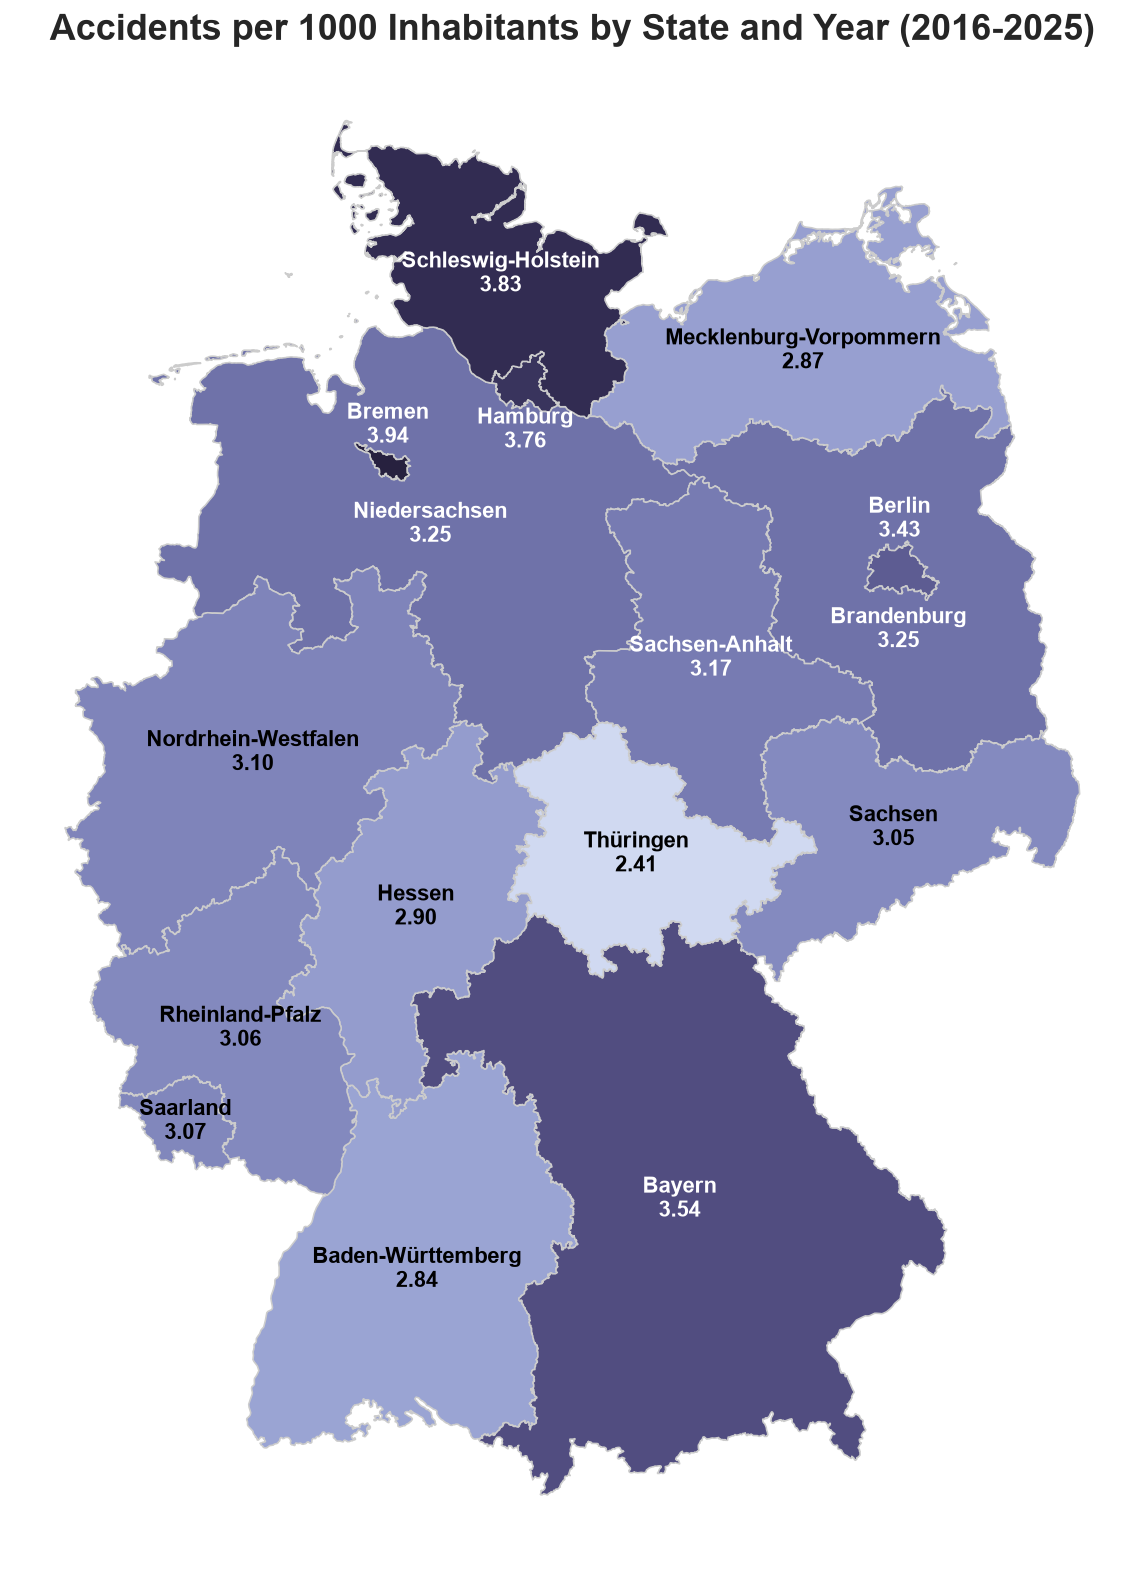

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14), dpi=144)
cmap = sns.color_palette("ch:s=.1,rot=-.1", 16, as_cmap=True)

merged_gdf.plot(
    column="AccidentsPer1000",
    cmap=cmap,
    linewidth=0.8,
    ax=ax,
    edgecolor="0.8",
    legend=False,
    missing_kwds={"color": "lightgrey", "label": "Missing values"},
    legend_kwds={
        "label": "Accidents per 1000 Inhabitants (Normalized)",
        "orientation": "horizontal",
    },
)

# Add annotations: dynamic threshold for the text color
threshold = merged_gdf["AccidentsPer1000"].median()

# Loop through each state to add text.
for idx, row in merged_gdf.iterrows():
    if pd.isna(row["AccidentsPer1000"]):
        continue

    # Automatically set text color based on the threshold.
    text_color = "white" if row["AccidentsPer1000"] > threshold else "black"

    # Get the default centroid coordinates
    centroid = row.geometry.centroid
    x = centroid.x
    y = centroid.y

    state_name = row["state"]
    value = row["AccidentsPer1000"]
    annotation_text = f"{state_name}\n{value:.2f}"

    # START: Label Offset Logic
    if state_name == "Brandenburg":
        y -= 0.3  # Nudge Brandenburg's label DOWN
    elif state_name == "Bremen":
        y += 0.22  # Nudge Bremen's label UP
    elif state_name == "Berlin":
        y += 0.3  # Nudge Berlin's label UP
    elif state_name == "Hamburg":
        y -= 0.25  # Nudge Hamburg's label DOWN
    # END: Label Offset Logic

    ax.annotate(
        text=annotation_text,
        xy=(x, y),  # Use the potentially modified x and y
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=text_color,
    )
ax.axis("off")
ax.set_title(
    f"Accidents per 1000 Inhabitants by State and Year ({YEARS[0]}-{YEARS[-1]})",
    fontdict={"fontsize": "18", "fontweight": "bold"},
)
plt.show()

Bremen has the most accidents per 1000 inhabitants and year (3.94), followed by Schleswig-Holstein (3.83) and Hamburg (3.76). Thüringen has the fewest (2.41), so Bremen's rate is 1.64x Thüringen's. The rates of states that joined late (e.g. Mecklenburg-Vorpommern, 6 years) rest on fewer years.

### Cities
The population table is by district, so the cities here are the independent cities (kreisfreie Städte), including Berlin and Hamburg. Cities inside a district, e.g. Hannover (Region Hannover) and Aachen (Städteregion Aachen), have no population of their own and are not ranked.

In [14]:
# Accidents per 1000 inhabitants and year for the 20 largest independent cities
df_district_year = fd.get_district_aggregate(
    YEARS, {"inj_light": "sum", "inj_serious": "sum", "inj_fatal": "sum"}
)
df_cities = (
    df_district_year[df_district_year["kreisfrei"]]
    .groupby("name")
    .agg(
        inj_total=("inj_total", "sum"),
        person_years=("population", "sum"),
        population=("population", "last"),  # latest year (rows are in year order)
    )
    .nlargest(20, "population")
)
df_cities["Accidents_per_1000"] = df_cities["inj_total"] / df_cities["person_years"] * 1000
df_cities = df_cities.sort_values("Accidents_per_1000", ascending=False)
df_cities

,inj_total,person_years,population,Accidents_per_1000
name,,,,
Köln,31120,7340262,1025523,4.239631
Bremen,22098,5736462,588413,3.852200
Bonn,8720,2282961,323587,3.819601
Dresden,21089,5571924,562764,3.784869
Hamburg,69384,18452176,1869473,3.760207
Nürnberg,19422,5200746,531159,3.734464
Düsseldorf,15897,4330724,619444,3.670749
Karlsruhe,11206,3095132,309247,3.620524
Berlin,100546,29336953,3700577,3.427282


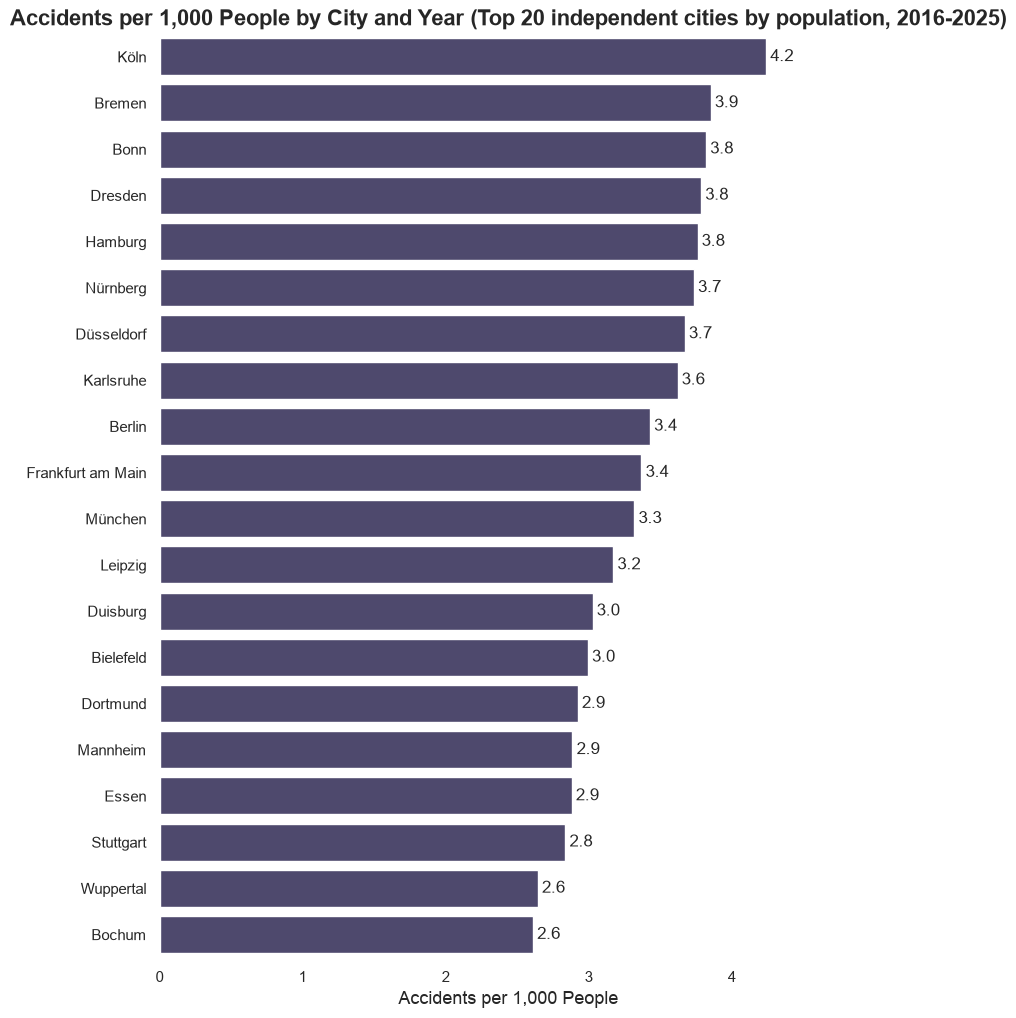

In [15]:
fig, ax = plt.subplots(figsize=(9, 12))
pl.hbar(
    df_cities.index,
    df_cities["Accidents_per_1000"],
    f"Accidents per 1,000 People by City and Year (Top 20 independent cities by population, {YEARS[0]}-{YEARS[-1]})",
    "Accidents per 1,000 People",
    "",
    fmt="{:.1f}",
    ax=ax,
)
ax.set_xlim(0, df_cities["Accidents_per_1000"].max() * 1.15)
ax.grid(False)
sns.despine(left=True, bottom=True)
plt.show()

Among the 20 largest independent cities, Köln (4.2), Bremen and Bonn (both 3.9) have the most accidents per 1000 inhabitants and year. Bochum, Wuppertal (both 2.6) and Stuttgart (2.8) have the fewest; several cities of the Ruhr area in Nordrhein-Westfalen are near the bottom. Frankfurt am Main is in the middle with 3.4.